# Imports

## 1.1 Libraries

In [1]:
import pandas as pd
import sys                          
import numpy as np             # Data manipulation 
from sklearn.decomposition import PCA        # The main algorithm
from matplotlib import pyplot as plt         # Graphing
import seaborn as sns                        # Graphing
from collections import defaultdict, Counter # Utils
sns.set(style="white")                       # Tuning the style of charts
import warnings                              # Disable some warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)

import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import plotly.graph_objects as go
import re

## 1.2 Datasets

In [2]:
data_factorySolarGen = pd.read_csv('Generacion_fotovoltaica.csv')
data_gridInput = pd.read_csv('Consumo.csv')
data_Weather = pd.read_csv('Meteorologia.csv')
data_CarbonIntensity23 = pd.read_csv('ES_2023_hourly.csv')
data_CarbonIntensity24 = pd.read_csv('ES_2024_hourly.csv')
data_CarbonIntensity = pd.concat([data_CarbonIntensity23, data_CarbonIntensity24], ignore_index=True)
data_factorySolarUse = pd.read_csv('Consumo_fotovoltaica.csv')



In [3]:
import pandas as pd

def filterData(df):
    df = df.drop(columns=df.filter(regex=r'^v\d{2}$').columns) # Drop validation columns
    df = df[df['magnitud']==88] # Solar radiation  only
    df = df[df['municipio']==65] # Getafe only
    df_clean = df.drop(columns=['punto_muestreo','provincia','municipio','estacion','magnitud'])
    return df_clean


def toLongForm(df):
    df_long = df.melt(
        id_vars=['ano', 'mes', 'dia'], 
        value_vars=[f'h{str(i).zfill(2)}' for i in range(1, 25)],
        var_name='hour',
        value_name='GETAFE_SOLAR'
    )

    df_long['hour'] = df_long['hour'].str.extract('h(\d+)').astype(int) - 1

    df_long = df_long.rename(columns={'ano': 'year', 'mes': 'month', 'dia': 'day'})

    df_long['TIMESTAMP'] = pd.to_datetime(df_long[['year', 'month', 'day']]) + pd.to_timedelta(df_long['hour'], unit='h')

    df_long['TIMESTAMP'] = pd.to_datetime(df_long['TIMESTAMP'])

    df_long = df_long[['TIMESTAMP', 'GETAFE_SOLAR']]

    df_long = df_long.sort_values(by='TIMESTAMP')

    df_long = df_long.set_index('TIMESTAMP')

    return df_long


<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
/var/folders/8m/_6ttb91j0dl6ptlnvls6lf040000gn/T/ipykernel_42838/165820959.py:19: SyntaxWarning: invalid escape sequence '\d'
  df_long['hour'] = df_long['hour'].str.extract('h(\d+)').astype(int) - 1


In [4]:
def renameAndIndex(df,datetime):
    df=df.rename(columns={datetime:'TIMESTAMP'})
    df['TIMESTAMP']=pd.to_datetime(df['TIMESTAMP'])
    df.set_index('TIMESTAMP', inplace=True)
    return df

In [5]:
data_factorySolarGen = renameAndIndex(data_factorySolarGen,'FECHA')
data_gridInput = renameAndIndex(data_gridInput,'FECHA')
data_Weather = renameAndIndex(data_Weather,'FORECAST_TIMESTAMP')
data_CarbonIntensity = renameAndIndex(data_CarbonIntensity,'Datetime (UTC)')
data_factorySolarUse = renameAndIndex(data_factorySolarUse,'FECHA')


In [6]:
allDatasets = {
    "factorySolarGen": data_factorySolarGen,
    "gridInput": data_gridInput,
    "weather": data_Weather,
    "carbonIntensity": data_CarbonIntensity,
    "factorySolarUse": data_factorySolarUse
}

minMaxDates = {}
for name, dataset in allDatasets.items():
    min_date = dataset.index.min()
    max_date = dataset.index.max()
    dataLen = len(dataset)
    minMaxDates[name] = {"min": min_date, "max": max_date, "rows":dataLen}

timeframes = pd.DataFrame(minMaxDates)

timeframes


,factorySolarGen,gridInput,weather,carbonIntensity,factorySolarUse
min,2023-07-24 11:00:00,2023-07-24 11:00:00,2023-07-24 11:00:00+00:00,2023-01-01 00:00:00,2024-09-01 00:00:00+02:00
max,2024-08-31 23:00:00,2024-08-31 23:00:00,2024-10-31 23:00:00+00:00,2024-12-31 23:00:00,2024-10-17 23:00:00+02:00
rows,9708,9708,100557,17544,1128


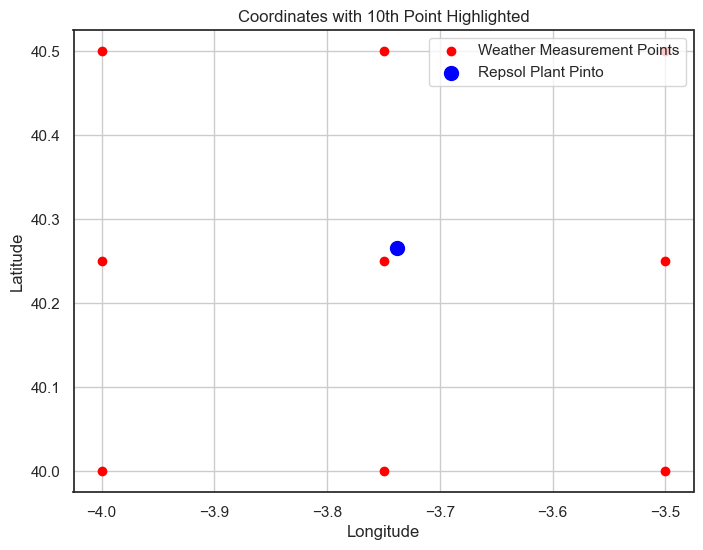

In [7]:
coords = data_Weather[['LATITUDE', 'LONGITUDE']].drop_duplicates().values.tolist()
repsolPintoCoords = [40.265468,-3.738145]

coords.append(repsolPintoCoords)
import folium

# Center map roughly on the middle point
center_lat = sum([lat for lat, _ in coords]) / len(coords)
center_lon = sum([lon for _, lon in coords]) / len(coords)

m = folium.Map(location=[center_lat, center_lon], zoom_start=10)

# Add all points to map
for i, (lat, lon) in enumerate(coords):
    icon_color = 'blue' if i == 9 else 'red'  # Different color for the 10th point
    folium.Marker(
        location=[lat, lon],
        popup=f'Point {i+1}',
        icon=folium.Icon(color=icon_color,icon='sun')
    ).add_to(m)

# Save to file
m.save("grid_points_map.html")

normal = coords[:-1]
special = coords[-1:]

plt.figure(figsize=(8, 6))

# Normal points in red
plt.scatter([lon for _, lon in normal], [lat for lat, _ in normal], color='red', label='Weather Measurement Points')

# Special point in blue
plt.scatter(special[0][1], special[0][0], color='blue', s=100, label='Repsol Plant Pinto')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Coordinates with 10th Point Highlighted')
plt.legend()
plt.grid(True)
plt.show()


In [8]:
coords = data_Weather[['LATITUDE', 'LONGITUDE']].drop_duplicates().values.tolist()
coords

# Since the weather data is collected from 9 distinct points, according to the EDA, we can average these 9 points to get an accurate reading, as we don't know exact factory location

data_Weather.groupby('TIMESTAMP').mean()


,LATITUDE,LONGITUDE,10uheightAboveGround_10,10vheightAboveGround_10,2rheightAboveGround_2,2shheightAboveGround_2,2theightAboveGround_2,SUNSDsurface_0,aptmpheightAboveGround_2,dlwrfsurface_0,...,spsurface_0,tccatmosphere_0,theightAboveGround_80,tmaxheightAboveGround_2,tminheightAboveGround_2,tozneatmosphereSingleLayer_0,tpsurface_0,tsurface_0,uheightAboveGround_80,vheightAboveGround_80
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-07-24 11:00:00+00:00,40.25,-3.75,5.176383,2.306685,17.577778,0.004644,301.823414,18000.0,300.332920,320.641024,...,94006.964236,2.700000,299.178662,301.843240,293.290378,324.906396,0.000000,315.466679,5.985768,2.433457
2023-07-24 12:00:00+00:00,40.25,-3.75,5.670802,2.579575,16.988889,0.004856,303.187798,21600.0,301.359812,324.429913,...,93949.704861,3.800000,300.411111,303.219008,293.290378,325.770036,0.000000,317.400000,6.652786,2.790844
2023-07-24 13:00:00+00:00,40.25,-3.75,6.260587,2.442148,17.077778,0.005225,304.332392,3600.0,302.303198,352.366667,...,93885.935417,38.833333,301.517803,304.326211,303.222222,326.296606,0.000000,318.032850,7.447305,2.665181
2023-07-24 14:00:00+00:00,40.25,-3.75,7.004427,2.025345,17.266667,0.005513,305.103729,7200.0,302.988475,356.926508,...,93829.203819,23.177778,302.366265,305.123018,303.222222,327.157633,0.000000,317.471498,8.407716,2.233926
2023-07-24 15:00:00+00:00,40.25,-3.75,7.471493,2.054768,17.411111,0.005703,305.553950,10800.0,303.401274,360.544444,...,93770.919444,58.177778,303.032275,305.617803,303.222222,330.289266,0.000000,315.935266,8.912477,2.333355
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-31 19:00:00+00:00,40.25,-3.75,1.712167,-0.120578,73.222222,0.008330,288.451378,0.0,288.458230,332.734110,...,94665.164583,42.044444,288.438051,289.342572,288.244711,295.169328,0.013889,287.852675,2.547099,0.112466
2024-10-31 20:00:00+00:00,40.25,-3.75,1.172493,0.060525,75.133333,0.008365,288.053681,0.0,288.046803,326.544554,...,94687.728819,54.911111,288.217674,289.467016,287.635614,295.584785,0.013889,287.270662,1.844787,0.230565
2024-10-31 21:00:00+00:00,40.25,-3.75,0.838918,0.100157,74.722222,0.008353,288.091836,0.0,288.100517,328.326836,...,94711.029167,71.344444,288.150030,289.579238,287.398305,295.179774,0.013889,287.248275,1.417429,0.248963


In [9]:
from geopy.distance import geodesic  # accurate distance calculation

grid_coords = coords
target_coord = repsolPintoCoords

distances = [geodesic(coord, target_coord).kilometers for coord in grid_coords]

inv_distances = [1/d if d != 0 else 1e9 for d in distances]  # Avoid division by zero
total = sum(inv_distances)
weights = [w/total for w in inv_distances]

point_names = [f"point{i+1}" for i in range(len(grid_coords))]
weight_mapping = dict(zip(point_names, weights))

In [10]:
point_labels = [f"point{i+1}" for i in range(len(coords))]

coord_to_label = {tuple(coord): label for coord, label in zip(coords, point_labels)}

data_Weather['point'] = data_Weather[['LATITUDE', 'LONGITUDE']].apply(
    lambda row: coord_to_label.get((row['LATITUDE'], row['LONGITUDE']), None),
    axis=1
)

data_Weather['weight'] = data_Weather['point'].map(weight_mapping)

columns_to_weight = [col for col in data_Weather.columns if col not in ['LATITUDE', 'LONGITUDE','point']]

for col in columns_to_weight:
    data_Weather[col] = data_Weather[col] * data_Weather['weight']


#data_Weather = data_Weather.groupby('TIMESTAMP').mean()

data_Weather = data_Weather[data_Weather['point']=='point5']

data_Weather = data_Weather.drop(columns=['point','weight','LATITUDE','LONGITUDE'])

data_Weather.index = data_Weather.index.tz_convert(None)

data_Weather

,10uheightAboveGround_10,10vheightAboveGround_10,2rheightAboveGround_2,2shheightAboveGround_2,2theightAboveGround_2,SUNSDsurface_0,aptmpheightAboveGround_2,dlwrfsurface_0,dswrfsurface_0,gustsurface_0,...,spsurface_0,tccatmosphere_0,theightAboveGround_80,tmaxheightAboveGround_2,tminheightAboveGround_2,tozneatmosphereSingleLayer_0,tpsurface_0,tsurface_0,uheightAboveGround_80,vheightAboveGround_80
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-07-24 11:00:00,4.136662,1.939803,11.159858,0.002942,193.545204,11544.681021,192.632002,204.474061,366.235764,5.066942,...,60339.079072,2.308936,191.756294,193.586425,187.602022,208.321458,0.0,202.993982,4.700674,1.996882
2023-07-24 12:00:00,4.307678,2.592292,11.223995,0.003145,194.249248,13853.617225,193.098209,207.039545,408.271231,5.599673,...,60305.433142,2.308936,192.411350,194.312023,187.602022,208.960887,0.0,204.148443,4.939632,2.682898
2023-07-24 13:00:00,4.673122,2.882559,11.095721,0.003322,195.011863,2308.936204,193.696144,225.698514,629.223598,5.838558,...,60264.305215,25.975532,193.114024,194.986520,194.271327,209.148961,0.0,204.390429,5.424271,3.029170
2023-07-24 14:00:00,5.401759,2.881759,10.903310,0.003435,195.542208,4617.872408,194.171293,228.295253,615.126260,6.548630,...,60230.883765,3.206856,193.722341,195.547453,194.271327,209.594304,0.0,203.709708,6.318892,3.086088
2023-07-24 15:00:00,5.597277,3.120834,11.223995,0.003644,195.859472,6926.808612,194.550071,229.931564,590.407815,7.073972,...,60187.344684,46.178724,194.292027,195.871920,194.271327,212.137319,0.0,202.631771,6.578494,3.470545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-31 19:00:00,2.690161,-0.362389,53.233807,0.005487,183.968939,0.000000,183.975472,196.929952,0.000000,3.854769,...,60766.474788,5.195106,184.080114,185.413502,183.770114,189.655161,0.0,183.686855,3.924756,-0.383241
2024-10-31 20:00:00,1.739002,0.115783,50.989008,0.005466,184.335285,0.000000,184.324460,197.029293,0.000000,2.061473,...,60775.359783,20.074918,184.545935,185.419916,183.746463,190.042771,0.0,183.776781,2.564279,0.221279
2024-10-31 21:00:00,1.404622,0.146191,50.860734,0.005443,184.331251,0.000000,184.351784,199.918352,0.000000,1.736955,...,60793.496557,62.469552,184.449103,185.464812,183.746764,189.733125,0.0,183.505874,2.083520,0.235929


In [11]:
data_All = pd.concat([
    data_Weather.add_prefix("W_"),
    data_factorySolarGen.add_prefix("SG_"),
    data_gridInput.add_prefix("GI_"),
], axis=1, join='outer')

data_All = data_All[(data_All.index>'2023-07-25')&(data_All.index<'2024-10-01')]

data_All

,W_10uheightAboveGround_10,W_10vheightAboveGround_10,W_2rheightAboveGround_2,W_2shheightAboveGround_2,W_2theightAboveGround_2,W_SUNSDsurface_0,W_aptmpheightAboveGround_2,W_dlwrfsurface_0,W_dswrfsurface_0,W_gustsurface_0,...,W_theightAboveGround_80,W_tmaxheightAboveGround_2,W_tminheightAboveGround_2,W_tozneatmosphereSingleLayer_0,W_tpsurface_0,W_tsurface_0,W_uheightAboveGround_80,W_vheightAboveGround_80,SG_TOTAL_KWH_ENERGIA,GI_TOTAL_KWH_ENERGIA
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-07-25 01:00:00,2.766361,-1.444303,24.500379,0.003757,187.853340,0.0,187.876484,202.352603,0.0,4.249933,...,188.549438,188.630032,187.838371,203.820773,0.0,186.691889,3.662784,-2.716726,0.0,110.063507
2023-07-25 02:00:00,2.622140,-1.138907,27.707234,0.003929,187.157423,0.0,187.112796,201.007227,0.0,3.729249,...,187.877266,188.632577,187.132862,202.629868,0.0,185.865653,3.231792,-2.302657,0.0,110.063507
2023-07-25 03:00:00,2.233882,-1.599228,29.118251,0.004049,186.964910,0.0,186.940060,200.290243,0.0,3.345747,...,187.673800,188.613919,186.876314,202.231360,0.0,185.675285,2.794408,-2.799250,0.0,110.063507
2023-07-25 04:00:00,1.754841,-1.310309,30.080308,0.004053,186.580839,0.0,186.574873,199.870907,0.0,2.182487,...,187.501040,188.607593,186.555628,201.784076,0.0,185.094536,1.830703,-2.208902,0.0,54.867619
2023-07-25 05:00:00,0.993990,-0.987727,31.555461,0.004049,186.064422,0.0,186.081427,199.466431,0.0,1.544254,...,187.399072,188.607593,186.042532,200.422649,0.0,184.157314,0.748354,-1.544372,0.0,54.867619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-30 19:00:00,0.576858,0.917306,16.034279,0.002853,189.504855,0.0,189.494388,207.639218,0.0,1.156888,...,190.997202,190.195472,189.504855,188.253297,0.0,187.760783,0.678673,1.126159,NaN,NaN
2024-09-30 20:00:00,0.364110,0.730518,17.060473,0.002899,189.012067,0.0,189.039681,207.025218,0.0,0.853867,...,190.872060,190.195472,189.012067,189.485063,0.0,187.156930,0.449041,0.883448,NaN,NaN
2024-09-30 21:00:00,0.458659,0.709988,17.252884,0.002848,188.691398,0.0,188.741967,206.203974,0.0,0.919450,...,190.656160,190.195472,188.691398,191.691640,0.0,186.660587,0.541201,0.864555,NaN,NaN


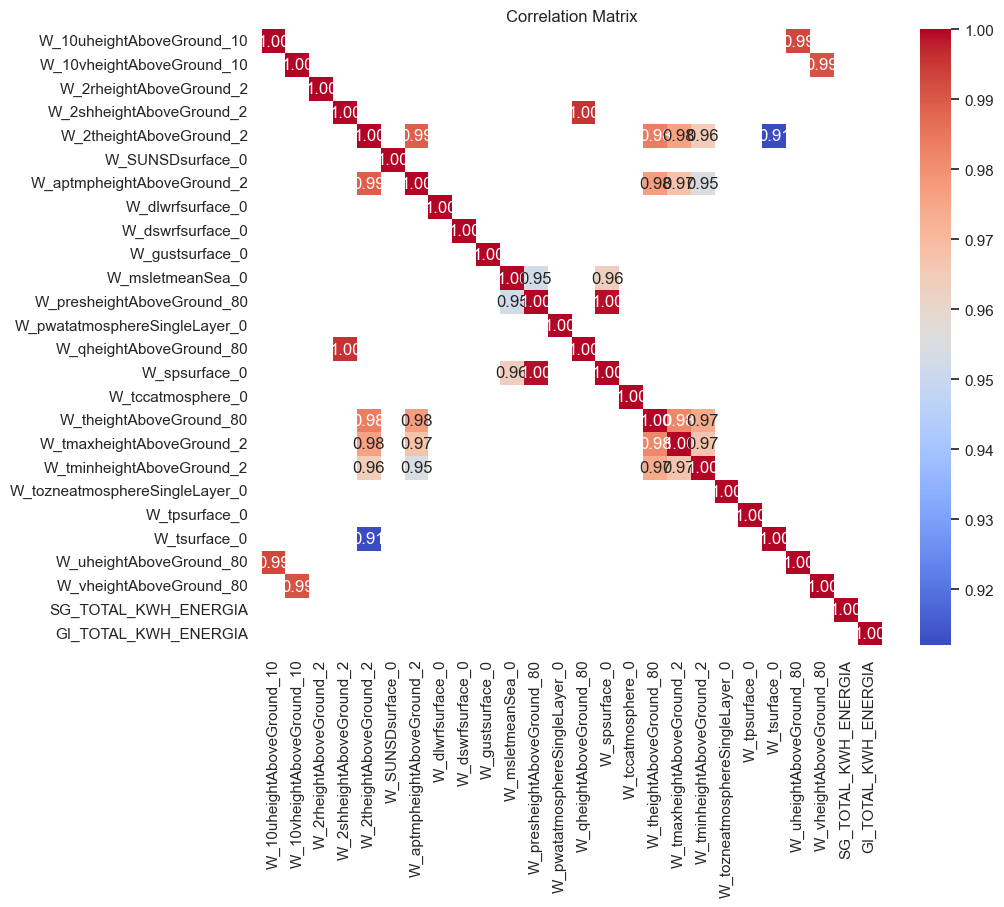

In [12]:
correlation_matrix = data_All.corr()
filtered_corr = correlation_matrix[correlation_matrix.abs() > 0.9]
plt.figure(figsize=(10, 8))
sns.heatmap(filtered_corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [13]:
data_AllDropFeatures = data_All.drop(columns=['W_2theightAboveGround_2','W_aptmpheightAboveGround_2','W_uheightAboveGround_80','W_qheightAboveGround_80','W_theightAboveGround_80','W_tminheightAboveGround_2', 'W_spsurface_0','W_vheightAboveGround_80', 'W_msletmeanSea_0'])

data_AllDropFeatures.to_csv('cleanDatav5.csv')

## Null Imputation/Drop

### Drop Nulls

In [14]:
data_AllDrop = data_All.dropna(subset=['SG_TOTAL_KWH_ENERGIA'])

data_AllDrop.to_csv('cleanDatav1.csv')

### KNN Imputation

In [15]:
# Select features for imputation
selected_features = ['W_dswrfsurface_0', 'W_SUNSDsurface_0', 'W_tsurface_0','SG_TOTAL_KWH_ENERGIA']
data_selected = data_All[selected_features]

# Scale data (KNN works better with standardized values)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_selected)

# Apply KNN imputation
imputer = KNNImputer(n_neighbors=3)
data_imputed_scaled = imputer.fit_transform(data_scaled)

# Reverse scaling
data_imputed = scaler.inverse_transform(data_imputed_scaled)

data_AllKNN = data_All.copy()

# Replace imputed values back into original DataFrame
data_AllKNN[selected_features] = data_imputed

data_AllKNN.to_csv('cleanDatav2.csv')

### Huber Regressor

In [16]:
import pandas as pd
import numpy as np
from sklearn.linear_model import HuberRegressor


# Splitting data into training (known A values) and missing values
train_df = data_All.dropna(subset=['SG_TOTAL_KWH_ENERGIA'])
test_df = data_All[data_All['SG_TOTAL_KWH_ENERGIA'].isnull()]

# Fit a robust regression model
model = HuberRegressor()
model.fit(train_df[['W_dswrfsurface_0']], train_df['SG_TOTAL_KWH_ENERGIA'])

data_AllHuber = data_All.copy()

# Predict missing values
data_AllHuber.loc[data_AllHuber['SG_TOTAL_KWH_ENERGIA'].isnull(), 'SG_TOTAL_KWH_ENERGIA'] = model.predict(test_df[['W_dswrfsurface_0']])

data_AllHuber.isna().mean()

data_AllKNN.to_csv('cleanDatav3.csv')

## Multiplier Impute

In [17]:
data_AllMult = data_All.copy()

(data_AllMult['W_dswrfsurface_0']/data_AllMult['SG_TOTAL_KWH_ENERGIA']).mean()

ratios = data_AllMult['W_dswrfsurface_0']/data_AllMult['SG_TOTAL_KWH_ENERGIA'].replace(0, np.nan)
average_multiplier = ratios.mean()

data_AllMult['SG_TOTAL_KWH_ENERGIA'] = data_AllMult['SG_TOTAL_KWH_ENERGIA'].fillna(
    data_AllMult['W_dswrfsurface_0'] / average_multiplier
)

data_AllMult.isna().mean()

data_AllMult.to_csv('cleanDatav4.csv')

In [18]:
data_All[(data_All['W_dswrfsurface_0']>200)&(data_All['SG_TOTAL_KWH_ENERGIA']<20)]

data_LogicCheck = data_All[~((data_All['W_dswrfsurface_0'] > 200) & (data_All['SG_TOTAL_KWH_ENERGIA'] < 20))]

data_LogicCheck.to_csv('cleanDatav0.csv')


len(data_All.columns)
#len(data_LogicCheck.columns)

26

In [19]:
def evaluateImpute(data, solar_gen,method):    
    data = data.sort_index()
    solar_gen = solar_gen.sort_values(by='FECHA')

    # Create figure
    fig = go.Figure()

    # Add first line (data)
    fig.add_trace(go.Scatter(x=data.index, y=data['TOTAL_KWH_ENERGIA'], 
                            mode='lines', name=f'{method} Imputed Values', line=dict(color='red')))

    # Add second line (solar_gen)
    fig.add_trace(go.Scatter(x=solar_gen['FECHA'], y=solar_gen['TOTAL_KWH_ENERGIA'], 
                            mode='lines', name='Solar Gen', line=dict(color='blue')))

    # Update layout
    fig.update_layout(title=f"Imputation of Solar Gen Nulls with {method} Imputed Values",
                    xaxis_title="Date/Index",
                    yaxis_title="Total kWh Energy",
                    legend_title="Dataset")

    # Show plot
    fig.show()

In [20]:
realValues = pd.read_csv('REPSOL_Correct.csv')

realValues['DATETIME'] = pd.to_datetime(realValues['DATETIME']).dt.tz_localize(None)
realValues = realValues.set_index('DATETIME')

testDF = pd.merge(data_Weather, realValues, right_index=True, left_index=True)

testDF[['dswrfsurface_0', 'CORRECTVALUES']].corr()

,dswrfsurface_0,CORRECTVALUES
dswrfsurface_0,1.000000,0.944807
CORRECTVALUES,0.944807,1.000000


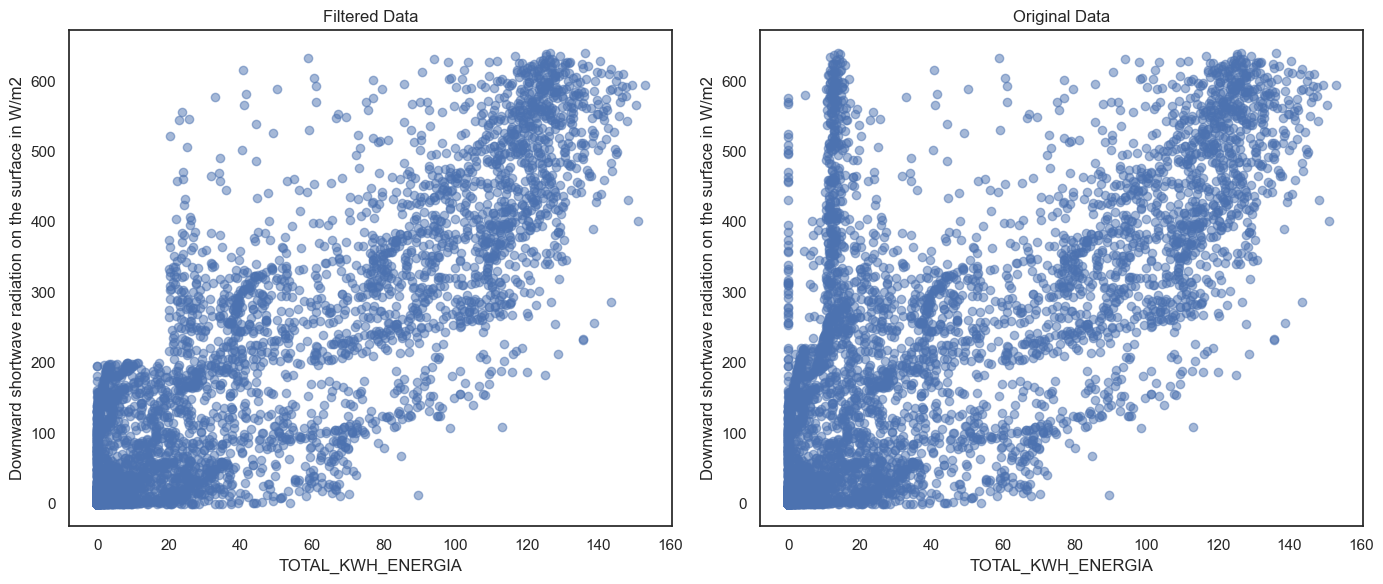

,W_dswrfsurface_0,SG_TOTAL_KWH_ENERGIA
W_dswrfsurface_0,1.000000,0.900464
SG_TOTAL_KWH_ENERGIA,0.900464,1.000000


In [21]:
import matplotlib.pyplot as plt

# Create subplots with 1 row and 2 columns
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))  # You can adjust figsize as needed

# First plot: Filtered data (data_LogicCheck)
axes[0].scatter(data_LogicCheck['SG_TOTAL_KWH_ENERGIA'], data_LogicCheck['W_dswrfsurface_0'], alpha=0.5)
axes[0].set_xlabel("TOTAL_KWH_ENERGIA")
axes[0].set_ylabel("Downward shortwave radiation on the surface in W/m2")
axes[0].set_title("Filtered Data")

# Second plot: Original data (data_All)
axes[1].scatter(data_All['SG_TOTAL_KWH_ENERGIA'], data_All['W_dswrfsurface_0'], alpha=0.5)
axes[1].set_xlabel("TOTAL_KWH_ENERGIA")
axes[1].set_ylabel("Downward shortwave radiation on the surface in W/m2")
axes[1].set_title("Original Data")

# Layout adjustment
plt.tight_layout()
plt.show()


data_LogicCheck[['W_dswrfsurface_0', 'SG_TOTAL_KWH_ENERGIA']].corr()



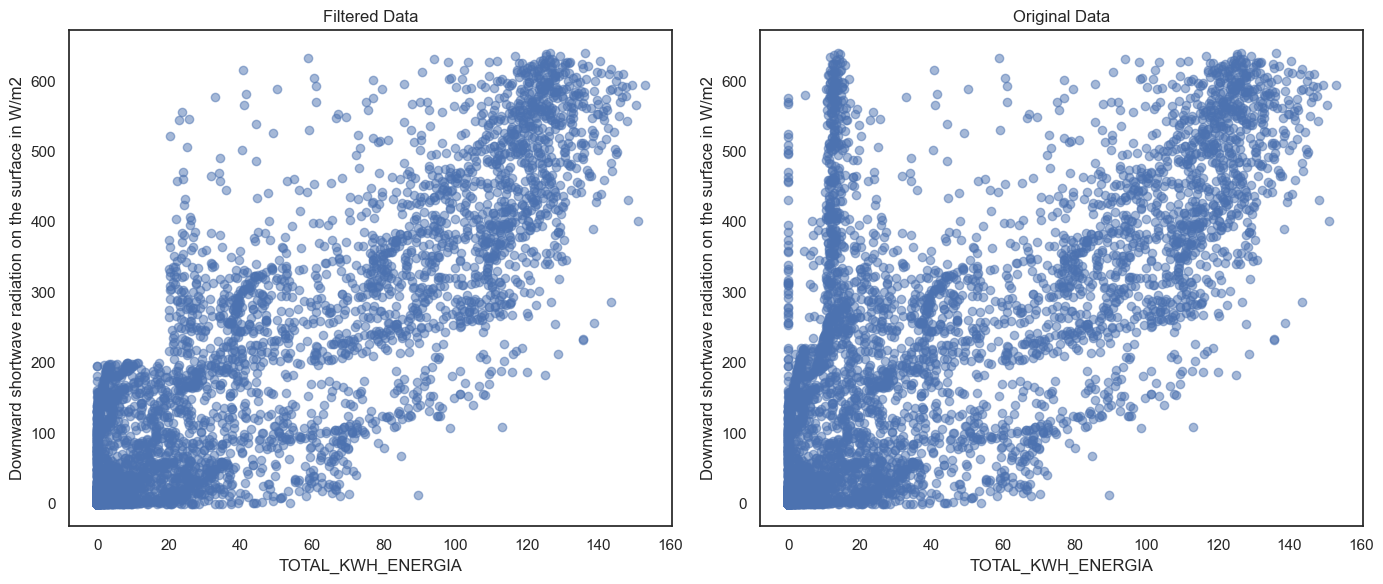

,W_dswrfsurface_0,SG_TOTAL_KWH_ENERGIA
W_dswrfsurface_0,1.000000,0.900464
SG_TOTAL_KWH_ENERGIA,0.900464,1.000000


In [22]:
import matplotlib.pyplot as plt

# Create subplots with 1 row and 2 columns
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))  # You can adjust figsize as needed

# First plot: Filtered data (data_LogicCheck)
axes[0].scatter(data_LogicCheck['SG_TOTAL_KWH_ENERGIA'], data_LogicCheck['W_dswrfsurface_0'], alpha=0.5)
axes[0].set_xlabel("TOTAL_KWH_ENERGIA")
axes[0].set_ylabel("Downward shortwave radiation on the surface in W/m2")
axes[0].set_title("Filtered Data")

# Second plot: Original data (data_All)
axes[1].scatter(data_All['SG_TOTAL_KWH_ENERGIA'], data_All['W_dswrfsurface_0'], alpha=0.5)
axes[1].set_xlabel("TOTAL_KWH_ENERGIA")
axes[1].set_ylabel("Downward shortwave radiation on the surface in W/m2")
axes[1].set_title("Original Data")

# Layout adjustment
plt.tight_layout()
plt.show()


data_LogicCheck[['W_dswrfsurface_0', 'SG_TOTAL_KWH_ENERGIA']].corr()



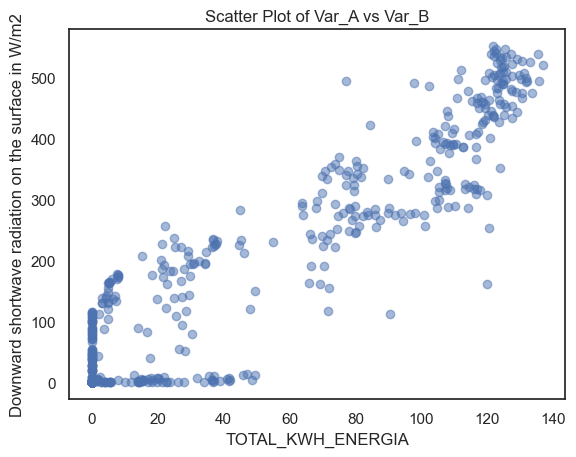

In [23]:
# Sample data
x = testDF['CORRECTVALUES']
y = testDF['dswrfsurface_0']

# Scatter plot
plt.scatter(x, y, alpha=0.5)
plt.xlabel("TOTAL_KWH_ENERGIA")
plt.ylabel("Downward shortwave radiation on the surface in W/m2")
plt.title("Scatter Plot of Var_A vs Var_B")
plt.show()